# 04_interrupts_hitl

对应 `index.md` 第 4 阶段：`interrupt_before` / `interrupt_after`、动态 `interrupt()` 与 `Command(resume=...)`、`update_state`。

笔记本在 `codes/langgraph/04_interrupts_hitl/qa.ipynb`。需要读写文件时，工作空间就是这个目录。

先运行下一格，得到 `ROOT` 并加载 `codes/langgraph/local.env`。每题只改 `# 作答` 下面的代码。前置代码不用改。做完自己跑通即可，先不要对答案。

上一阶段靠 checkpointer 把 state 存了下来，但 `invoke` 还是一口气跑到底。真实 Agent 常需要人在中间看一眼：**断点**让图停下来，**`update_state`** 让人改写 state，**`Command(resume=...)`** 把人的输入送回被中断的节点。一个容易混的点：静态断点（`interrupt_before` / `interrupt_after`）的返回结果里**没有** `__interrupt__`，它停在哪要看 `get_state(config).next`；动态 `interrupt()` 才会在返回结果里给出 `__interrupt__`。第 1 题起都要调 API。


In [1]:
import os
from pathlib import Path

def lab_root() -> Path:
    """qa.ipynb 所在目录。"""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        if folder.name == "04_interrupts_hitl" and (folder / "qa.ipynb").is_file():
            return folder
        candidate = folder / "codes" / "langgraph" / "04_interrupts_hitl"
        if (candidate / "qa.ipynb").is_file():
            return candidate
    return here

def load_local_env(env_path: Path) -> None:
    """把 local.env 写入 os.environ（已有键不覆盖）。"""
    if not env_path.is_file():
        return
    for raw in env_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key = key.strip()
        value = value.strip().strip("\"'")
        if key and key not in os.environ:
            os.environ[key] = value

ROOT = lab_root()
load_local_env(ROOT.parent / "local.env")
ROOT, bool(os.environ.get("DEEPSEEK_API_KEY"))


(PosixPath('/Users/keyficller/Documents/AEFS-Notes/codes/langgraph/04_interrupts_hitl'),
 True)

## 1. `interrupt_before`：把人放进来审一眼

`compile(..., interrupt_before=["writer"])` 会在 `writer` 执行**之前**钉一个断点。第一次 `invoke` 跑到断点就返回；再用 `invoke(None, config)` 从断点继续。

已有 `model`、两个节点 `researcher` / `writer`、建好的 `graph`（`START → researcher → writer → END`），以及 `config`（`thread_id = "hitl-1"`）。

1. `app = graph.compile(checkpointer=MemorySaver(), interrupt_before=["writer"])`
2. `app.invoke({"messages": [HumanMessage("开始")]}, config)`，打印返回的消息条数和 `list(result.keys())`
3. `snap = app.get_state(config)`，打印 `snap.next`
4. `app.invoke(None, config)` 续跑，打印最终消息条数和最后一条 `content`

返回的 keys 里没有 `__interrupt__`——静态断点停在哪儿，只能从 `get_state` 看。`next` 指向还没执行的节点。


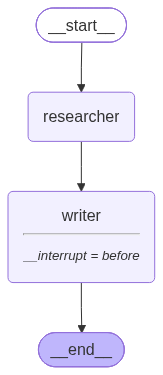

2
在标准大气压下，水的沸点是100摄氏度（212华氏度）。
('writer',)
3
在标准大气压条件下，水的沸点为100摄氏度（即212华氏度）。


In [5]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

def researcher(state: MessagesState) -> dict:
    return {"messages": [model.invoke([HumanMessage("用一句话说：水的沸点是多少。")])]}

def writer(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"] + [HumanMessage("把上面那句话改写得更正式。")])]}

graph = StateGraph(MessagesState)
graph.add_node("researcher", researcher)
graph.add_node("writer", writer)
graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", END)

config = {"configurable": {"thread_id": "hitl-1"}}

# 作答

app = graph.compile(checkpointer=MemorySaver(), interrupt_before=["writer"])

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

result = app.invoke({"messages": [HumanMessage("开始")]}, config)

print(len(result["messages"]))
print(result["messages"][-1].content)

snap = app.get_state(config)
print(snap.next)

result = app.invoke(None, config)

print(len(result["messages"]))
print(result["messages"][-1].content)
#评阅
# 对。`interrupt_before=["writer"]` 让第一次 invoke 停在 writer 前：2 条消息、next == ('writer',)；
# invoke(None, config) 续跑后 3 条。
# 少做一步：题目第 2 点要打印 `list(result.keys())`，你打的是 len + content。静态断点的返回里**没有**
# `__interrupt__`，keys 就是 ['messages']——这正是它和动态 interrupt() 的分界，值得亲手看一眼。
# 另外 draw_mermaid_png() 画的是普通图，不会标出断点，留作对照可以，信息量有限。

#参考答案
# app = graph.compile(checkpointer=MemorySaver(), interrupt_before=["writer"])
# result = app.invoke({"messages": [HumanMessage("开始")]}, config)
# print(len(result["messages"]), list(result.keys()))    # 2 ['messages']，没有 __interrupt__
# print(app.get_state(config).next)                      # ('writer',)
# final = app.invoke(None, config)
# print(len(final["messages"]), final["messages"][-1].content)



## 2. `interrupt_after`：在节点后面停

`interrupt_after=["researcher"]` 在 `researcher` 执行**之后**、`writer` 开始之前停下。对一条边来说，「`after` 上一个节点」和「`before` 下一个节点」钉在同一个位置。

已有 `model`、`researcher` / `writer`、建好的 `graph`，以及两个线程 id：`thread_edge = "edge-after"`、`thread_tail = "tail-after"`。

1. 用 `interrupt_after=["researcher"]` 编译 `app_edge`，在 `thread_edge` 上 `invoke`，打印 `app_edge.get_state(config_edge).next` 和消息条数
2. 用 `interrupt_after=["writer"]` 编译 `app_tail`，在 `thread_tail` 上 `invoke`，打印 `app_tail.get_state(config_tail).next` 和消息条数
3. 对比两次 `next`：一个是 `('writer',)`，另一个是空元组 `()`。想一想为什么。

`.next` 的含义始终是「下一步要执行的节点」——`writer` 已经跑完、后面没有节点，自然就是 `()`。


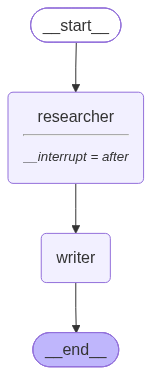

2
在标准大气压（1 atm）下，水的沸点是100摄氏度（373.15 K）。
2
('writer',)


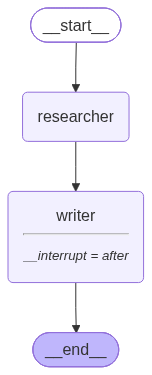

3
在标准大气压（1 atm）条件下，水的沸点为100摄氏度。
3
()


In [10]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

def researcher(state: MessagesState) -> dict:
    return {"messages": [model.invoke([HumanMessage("用一句话说：水的沸点是多少。")])]}

def writer(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"] + [HumanMessage("把上面那句话改写得更正式。")])]}

graph = StateGraph(MessagesState)
graph.add_node("researcher", researcher)
graph.add_node("writer", writer)
graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", END)

thread_edge = "edge-after"
thread_tail = "tail-after"

# 作答

app_edge = graph.compile(
    checkpointer=MemorySaver(),
    interrupt_after=["researcher"])

from IPython.display import Image, display
display(Image(app_edge.get_graph().draw_mermaid_png()))

thread_configs = {
    thread : {
        "configurable": {
            "thread_id": thread
        }
    }
    for thread in [thread_edge, thread_tail]
}

result = app_edge.invoke({"messages": [HumanMessage("开始")]}, thread_configs[thread_edge])

print(len(result["messages"]))
print(result["messages"][-1].content)

snap = app_edge.get_state(thread_configs[thread_edge])
print(len(snap.values["messages"]))
print(snap.next)


app_tail = graph.compile(
    checkpointer=MemorySaver(),
    interrupt_after=["writer"]
)

from IPython.display import Image, display
display(Image(app_tail.get_graph().draw_mermaid_png()))

result = app_tail.invoke({"messages": [HumanMessage("开始")]}, thread_configs[thread_tail])

print(len(result["messages"]))
print(result["messages"][-1].content)

snap = app_tail.get_state(thread_configs[thread_tail])
print(len(snap.values["messages"]))
print(snap.next)
#评阅
# 对。interrupt_after=["researcher"] → 2 条、next ('writer',)；interrupt_after=["writer"] → 3 条、next ()。
# 同一条边上「after 上游」和「before 下游」钉在同一位置，收尾断点则退化成空元组，两点都对上了。
# 小点：thread_configs 那个字典推导只有两个固定线程，直接写 config_edge / config_tail 更直白
# （和上一阶段同一处小习惯）；`from IPython.display import ...` 每题重复 import，挪到开头那格更干净。

#参考答案
# config_edge = {"configurable": {"thread_id": thread_edge}}
# config_tail = {"configurable": {"thread_id": thread_tail}}
# app_edge = graph.compile(checkpointer=MemorySaver(), interrupt_after=["researcher"])
# app_edge.invoke({"messages": [HumanMessage("开始")]}, config_edge)
# snap = app_edge.get_state(config_edge)
# print(len(snap.values["messages"]), snap.next)
# app_tail = graph.compile(checkpointer=MemorySaver(), interrupt_after=["writer"])
# app_tail.invoke({"messages": [HumanMessage("开始")]}, config_tail)
# snap = app_tail.get_state(config_tail)
# print(len(snap.values["messages"]), snap.next)











## 3. `update_state`：在断点处替人改写 state

停下之后，人可以直接往 state 里写东西再放行。`app.update_state(config, values, as_node=...)` 会把 `values` 当成某个节点的输出合并进 state。

已有 `model`、`researcher` / `writer`、建好的 `graph`，以及装好断点的 `app`（`interrupt_before=["writer"]`）和 `config`（`thread_id = "edit-1"`）。前置代码已经跑过第一次，图正停在 `writer` 前面。

1. `app.update_state(config, {"messages": [AIMessage("人类补充：必须提到标准大气压。")]}, as_node="researcher")`
2. `snap = app.get_state(config)`；打印消息条数、`snap.next`、最后一条 `content`
3. `app.invoke(None, config)` 续跑，打印最终最后一条 `content`

`update_state` 只动 state，图没有往前走；`next` 仍是 `('writer',)`，得再 `invoke(None, ...)` 才继续。


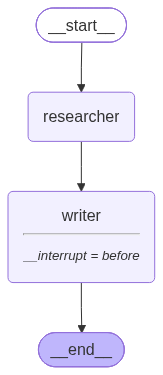

3
('writer',)
人类补充：必须提到标准大气压。
4
在标准大气压（即1个大气压）条件下，水的沸点为100摄氏度（212华氏度）。


In [13]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

def researcher(state: MessagesState) -> dict:
    return {"messages": [model.invoke([HumanMessage("用一句话说：水的沸点是多少。")])]}

def writer(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"] + [HumanMessage("把上面那句话改写得更正式。")])]}

graph = StateGraph(MessagesState)
graph.add_node("researcher", researcher)
graph.add_node("writer", writer)
graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", END)

config = {"configurable": {"thread_id": "edit-1"}}

app = graph.compile(checkpointer=MemorySaver(), interrupt_before=["writer"])
app.invoke({"messages": [HumanMessage("开始")]}, config)

# 作答

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

app.update_state(
    config,
    {"messages": [AIMessage("人类补充：必须提到标准大气压。")]},
    as_node="researcher"
)

snap = app.get_state(config)
print(len(snap.values["messages"]))
print(snap.next)
print(snap.values["messages"][-1].content)

result = app.invoke(None, config)

print(len(result["messages"]))
print(result["messages"][-1].content)
#评阅
# 对。update_state(..., as_node="researcher") 把那条人类消息当成 researcher 的输出合并进 messages：
# 3 条、next 仍是 ('writer',)、最后一条就是注入的句子；invoke(None) 后 4 条，writer 带着这条补充改写。
# 顺带确认一点：update_state 只写 state，不推进图；next 不变说明它没往前走，要继续还得 invoke(None, ...)。

#参考答案
# app.update_state(config, {"messages": [AIMessage("人类补充：必须提到标准大气压。")]}, as_node="researcher")
# snap = app.get_state(config)
# print(len(snap.values["messages"]), snap.next, snap.values["messages"][-1].content)
# final = app.invoke(None, config)
# print(final["messages"][-1].content)



## 4. 动态 `interrupt()` + `Command(resume=...)`

静态断点只能钉在节点边界上。要在节点**内部**停下来问人，用 `interrupt(payload)`：执行到这里会暂停，返回结果里多出一个 `__interrupt__`；再用 `Command(resume=人的答复)` 续跑，`interrupt(...)` 这次直接返回那个答复。

已有节点 `ask`（先 `interrupt({"question": ..., "draft": ...})`，拿到答复后写进一条 `AIMessage`）、建好的 `graph`（`START → ask → END`）、带 checkpointer 的 `app`，以及 `config`（`thread_id = "dyn-1"`）。

1. `result = app.invoke({"messages": [HumanMessage("草稿：水的沸点是 100 度。")]}, config)`
2. 打印 `result["__interrupt__"][0].value`，以及 `app.get_state(config).next`
3. `app.invoke(Command(resume="批准"), config)`，打印最后一条 `content`

`Command(resume=...)` 会让被中断的节点**从头再跑一遍**，只是这次 `interrupt()` 不暂停、直接返回你给的值——所以 `interrupt()` 之前的代码必须能安全重跑。


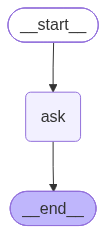

{'question': '这份草稿可以发布吗？', 'draft': '草稿：水的沸点是 100 度。'}
('ask',)
2
人的答复是：批准


In [16]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.types import Command, interrupt

def ask(state: MessagesState) -> dict:
    answer = interrupt(
        {"question": "这份草稿可以发布吗？", "draft": state["messages"][-1].content}
    )
    return {"messages": [AIMessage(f"人的答复是：{answer}")]}

graph = StateGraph(MessagesState)
graph.add_node("ask", ask)
graph.add_edge(START, "ask")
graph.add_edge("ask", END)

app = graph.compile(checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "dyn-1"}}

# 作答

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

result = app.invoke({"messages": [HumanMessage("草稿：水的沸点是 100 度。")]}, config)

print(result["__interrupt__"][0].value)
print(app.get_state(config).next)

result = app.invoke(Command(resume="批准"), config)

print(len(result["messages"]))
print(result["messages"][-1].content)
#评阅
# 对。第一次 invoke 的返回里带 __interrupt__，[0].value 就是那个 payload；此时 next == ('ask',)，
# 说明图停在 ask 内部；Command(resume="批准") 续跑后 interrupt 直接返回「批准」，2 条消息最后一条是它。
# 提醒一句（题面也强调过）：resume 会让 ask **从头再跑**，interrupt 之前的语句会重放。这题前面只取了
# state["messages"][-1].content，安全；若那之前有写文件 / 发请求，就得自己保证幂等。

#参考答案
# result = app.invoke({"messages": [HumanMessage("草稿：水的沸点是 100 度。")]}, config)
# print(result["__interrupt__"][0].value)      # {'question': ..., 'draft': ...}
# print(app.get_state(config).next)            # ('ask',)
# final = app.invoke(Command(resume="批准"), config)
# print(final["messages"][-1].content)         # 人的答复是：批准




## 5. 综合：审批通过 / 打回

把动态中断用成一道闸门：人回 `ok` 就放行，回别的就当作打回原因。

已有节点 `review`（`interrupt({...})` 拿到人的答复；答复是 `ok` 就返回一条「已批准」的 `AIMessage`，否则返回一条带原因的「已打回」）、建好的 `graph`、带 checkpointer 的 `app`，以及两个线程 id `thread_ok = "review-ok"`、`thread_reject = "review-reject"`。

1. 在 `thread_ok` 上 `invoke` 触发中断，用 `Command(resume="ok")` 续跑，打印最后一条 `content`
2. 在 `thread_reject` 上同样触发中断，用 `Command(resume="打回，改成标准大气压")` 续跑，打印最后一条 `content`
3. 两条线程共用一个 `app`，互不影响

触发中断的那次 `invoke`，返回结果自带 `__interrupt__`；人只看 payload 就够了，不需要再 `get_state`。


In [ ]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.types import Command, interrupt

def review(state: MessagesState) -> dict:
    reply = interrupt(
        {
            "draft": state["messages"][-1].content,
            "ask": "回复 ok 表示通过；回复其他内容表示打回，并说明原因。",
        }
    )
    if str(reply).strip().lower() == "ok":
        return {"messages": [AIMessage("已批准并发布。")]}
    return {"messages": [AIMessage(f"已打回，原因：{reply}")]}

graph = StateGraph(MessagesState)
graph.add_node("review", review)
graph.add_edge(START, "review")
graph.add_edge("review", END)

app = graph.compile(checkpointer=MemorySaver())
thread_ok = "review-ok"
thread_reject = "review-reject"

# 作答

app.invoke(
    {"messages": [HumanMessage("草稿：水的沸点是 100 度。")]},
    {"configurable": {"thread_id": thread_ok}}
)

result_ok = app.invoke(Command(resume="ok"), {"configurable": {"thread_id": thread_ok}})

print(len(result_ok["messages"]))
print(result_ok["messages"][-1].content)

result_reject = app.invoke(
    {"messages": [HumanMessage("草稿：水的沸点是 100 度。")]},
    {"configurable": {"thread_id": thread_reject}}
)

result_reject = app.invoke(Command(resume="打回，改成标准大气压"), {"configurable": {"thread_id": thread_reject}})

print(len(result_reject["messages"]))
print(result_reject["messages"][-1].content)
#评阅
# 对。两条线程共用一个 app：ok 得到「已批准并发布。」，其他文本得到「已打回，原因：…」，互不串线，
# 各自 2 条消息——动态中断当闸门这套用法你已经用顺了。
# 小点：result_reject 被赋值两次，第一次（带 __interrupt__ 的那次）没打印就被覆盖。这题只看最终答复没问题，
# 想顺手看一眼中断 payload 的话，给第一次的返回值换个名字即可。

#参考答案
# cfg_ok = {"configurable": {"thread_id": thread_ok}}
# cfg_reject = {"configurable": {"thread_id": thread_reject}}
# app.invoke({"messages": [HumanMessage("草稿：水的沸点是 100 度。")]}, cfg_ok)
# ok = app.invoke(Command(resume="ok"), cfg_ok)
# print(ok["messages"][-1].content)      # 已批准并发布。
# app.invoke({"messages": [HumanMessage("草稿：水的沸点是 100 度。")]}, cfg_reject)
# rej = app.invoke(Command(resume="打回，改成标准大气压"), cfg_reject)
# print(rej["messages"][-1].content)     # 已打回，原因：打回，改成标准大气压









2
已批准并发布。
1
草稿：水的沸点是 100 度。
2
已打回，原因：打回，改成标准大气压
